# Asimetría y fragilidad
Gini y p-impact

In [4]:
import importlib
import src.network_metrics
importlib.reload(src.network_metrics)
import pandas as pd
import networkx as nx
from src.network_metrics import build_metrics_dataframe, calculate_gini_index, calculate_p_impact_index, calculate_zimmermann_p_impact
from pathlib import Path

# 1. Cargar tu grafo desde la capa Gold
df_nodes = pd.read_parquet("data/03_gold/gold_nodes_2026-05-06.parquet")
df_edges = pd.read_parquet("data/03_gold/gold_edges_2026-05-06.parquet")

# 2. Armar los grafos
G_std = nx.DiGraph()
G_fail = nx.DiGraph()

G_std.add_nodes_from(df_nodes['node_name'])
G_fail.add_nodes_from(df_nodes['node_name'])

G_std.add_edges_from(zip(df_edges['source_node'], df_edges['target_node']))
# G_fail invierte la dirección (target -> source) para propagar el daño
G_fail.add_edges_from(zip(df_edges['target_node'], df_edges['source_node']))

total_nodes = G_std.number_of_nodes()

# 3. Calcular PageRank al vuelo (La métrica estructural)
print("Calculando PageRank de la red...")
pagerank_scores = nx.pagerank(G_std, alpha=0.85)

# 2. Obtener todas las métricas limpias
df_metrics = build_metrics_dataframe(G_fail)

# 3. Calcular métricas de ecosistema
gini = calculate_gini_index(df_metrics['transitive_reverse_deps'].values)
p_impact_5 = calculate_p_impact_index(G_fail, p_threshold_percent=5.0)
p_impact_Z = calculate_zimmermann_p_impact(G_fail, pagerank_scores)

print(f"Desigualdad de dependencias (Gini): {gini:.3f}")
print(f"Paquetes P-Impact (5%): {p_impact_5} paquetes pueden tumbar el ecosistema.")
print(f"Paquetes P-Impact Zimmerman (5%): {p_impact_Z} paquetes pueden tumbar el ecosistema.")

Calculando PageRank de la red...
Desigualdad de dependencias (Gini): 0.890
Paquetes P-Impact (5%): 20 paquetes pueden tumbar el ecosistema.
Paquetes P-Impact Zimmerman (5%): 18 paquetes pueden tumbar el ecosistema.


# Fragilidad/robustez
Desde la óptica de Decan (2016)

Calculando evolución del P-Impact (Decan) y P-Impact Ponderado (Zimmermann) para 6 snapshots...



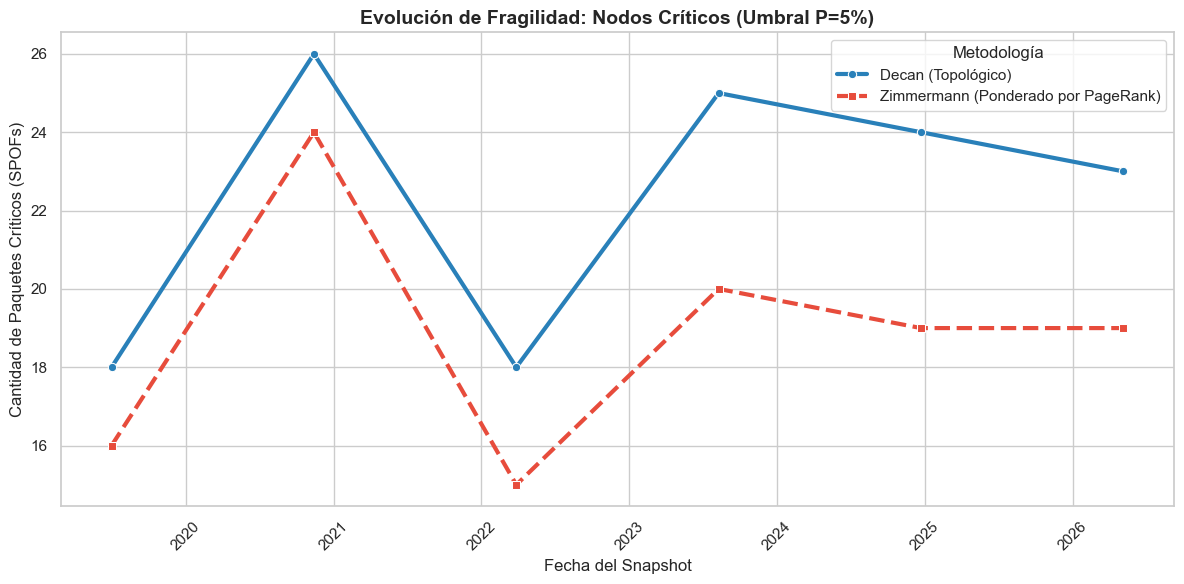

--- RESUMEN HISTÓRICO: PAQUETES CRÍTICOS ---


,Fecha,P-Impact (Decan),P-Impact (Zimmermann)
0,2019-07-02,18,16
1,2020-11-13,26,24
2,2022-03-28,18,15
3,2023-08-10,25,20
4,2024-12-22,24,19
5,2026-05-06,23,19


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.network_metrics import calculate_p_impact_index, calculate_zimmermann_p_impact

# --- Configuración ---
gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"

# Muestreo de 6 snapshots
all_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")
target_dates = all_dates[::-5][::-1]

results = []
print(f"Calculando evolución del P-Impact (Decan) y P-Impact Ponderado (Zimmermann) para {len(target_dates)} snapshots...\n")

# --- Loop Evolutivo ---
for ts in target_dates:
    date_str = ts.strftime('%Y-%m-%d')
    edge_file = gold_dir / f"gold_edges_{date_str}.parquet"
    
    if not edge_file.exists():
        print(f" [!] Omitiendo {date_str}: Datos no encontrados.")
        continue
        
    # Cargar datos e inicializar grafo estándar
    df_edges = pd.read_parquet(edge_file)
    G_std = nx.from_pandas_edgelist(df_edges, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    if G_std.number_of_nodes() == 0:
        continue
        
    # Crear G_fail invirtiendo G_std (el daño viaja de target a source)
    G_fail = G_std.reverse(copy=True)
    
    # Precalcular PageRank en G_std para la métrica de Zimmermann
    pagerank_scores = nx.pagerank(G_std, alpha=0.85)
    
    # 2. Calcular los índices (Umbral por defecto P=5.0)
    p_impact_decan = calculate_p_impact_index(G_fail, p_threshold_percent=5.0)
    p_impact_zimmermann = calculate_zimmermann_p_impact(G_fail, pagerank_scores, p_threshold_percent=5.0)
    
    results.append({
        'Fecha': ts,
        'P-Impact (Decan)': p_impact_decan,
        'P-Impact (Zimmermann)': p_impact_zimmermann
    })

df_impact = pd.DataFrame(results)

# --- Visualización ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_impact, x='Fecha', y='P-Impact (Decan)', 
             color='#2980B9', linewidth=3, marker='o', label='Decan (Topológico)')
             
sns.lineplot(data=df_impact, x='Fecha', y='P-Impact (Zimmermann)', 
             color='#E74C3C', linewidth=3, marker='s', linestyle='--', label='Zimmermann (Ponderado por PageRank)')

plt.title("Evolución de Fragilidad: Nodos Críticos (Umbral P=5%)", fontsize=14, fontweight='bold')
plt.ylabel("Cantidad de Paquetes Críticos (SPOFs)", fontsize=12)
plt.xlabel("Fecha del Snapshot", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Metodología", fontsize=11)

plt.tight_layout()
plt.show()

print("--- RESUMEN HISTÓRICO: PAQUETES CRÍTICOS ---")
display(df_impact)

Calculando métricas de Decan (2018) para 30 snapshots.
Esto puede tomar unos minutos debido al cálculo de dependencias transitivas...



/var/folders/v5/kbcdcc412tb1kkysqm2lplxm0000gq/T/ipykernel_45657/1360262165.py:89: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()                               # Ajuste de márgenes
/var/folders/v5/kbcdcc412tb1kkysqm2lplxm0000gq/T/ipykernel_45657/1360262165.py:89: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()                               # Ajuste de márgenes
/Users/manumoreira/Repos/my_venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


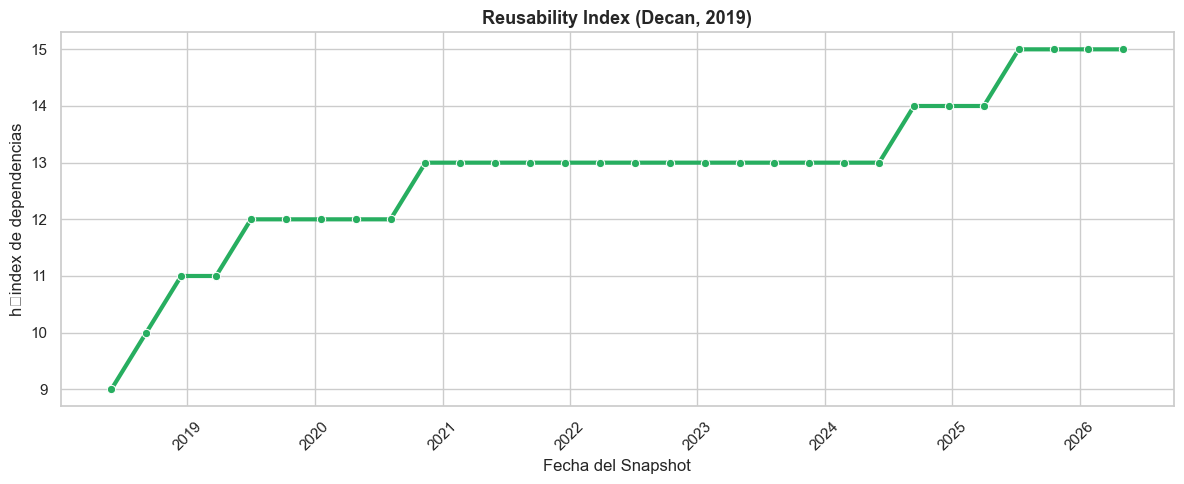

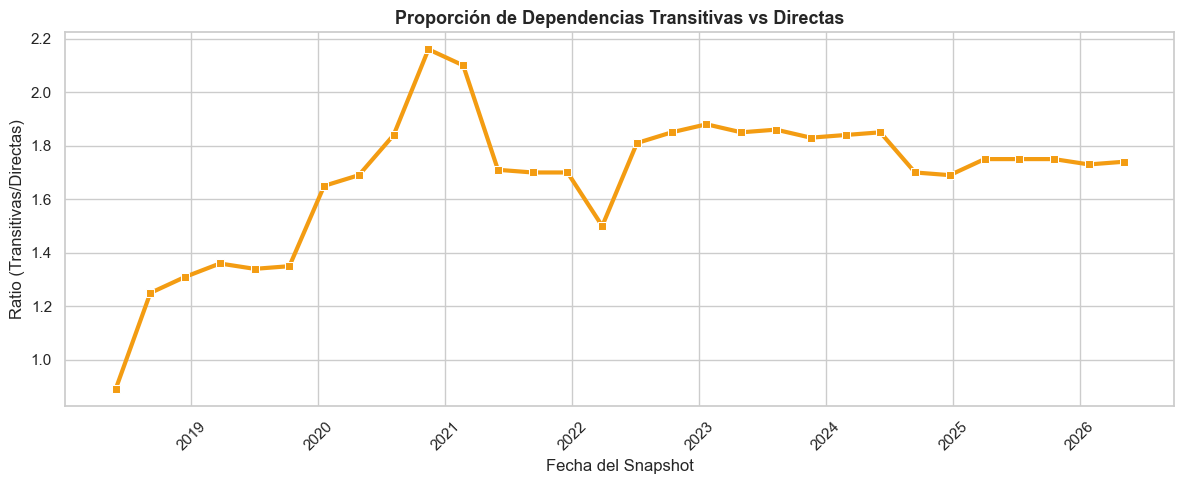

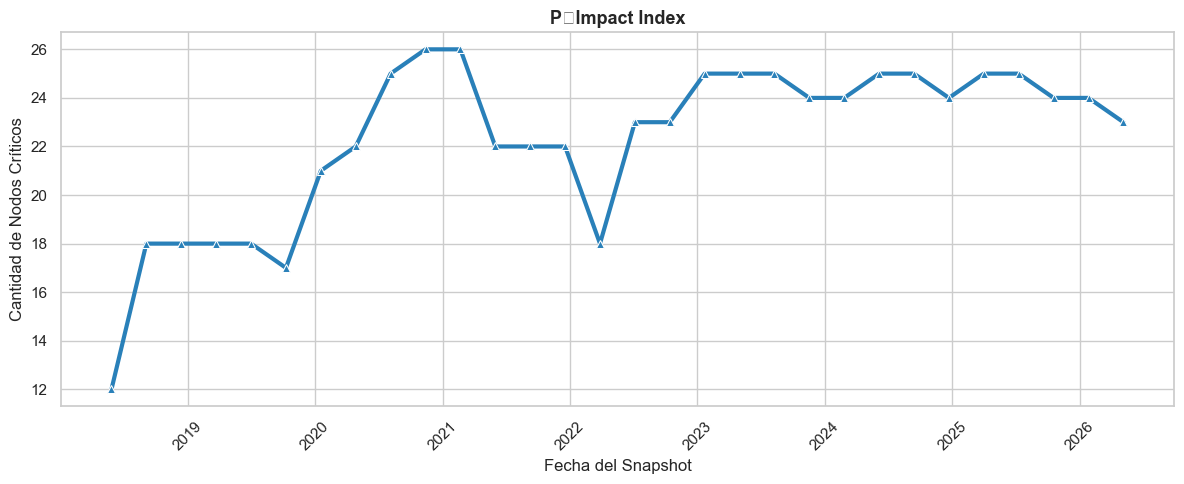

--- RESUMEN HISTÓRICO: MÉTRICAS DE DECAN (2018) ---


,Fecha,P-Impact (5%),Reusability Index,Transitive/Direct Ratio
0,2018-05-28,12,9,0.89
1,2018-09-05,18,10,1.25
2,2018-12-14,18,11,1.31
3,2019-03-24,18,11,1.36
4,2019-07-02,18,12,1.34
5,2019-10-10,17,12,1.35
6,2020-01-18,21,12,1.65
7,2020-04-27,22,12,1.69
8,2020-08-05,25,12,1.84
9,2020-11-13,26,13,2.16


In [20]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.network_metrics import (
    calculate_p_impact_index,
    calculate_reusability_index, 
    calculate_transitive_direct_ratio
)

# --- 1. Configuración ---
gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"

# Generamos los 30 snapshots históricos completos (sin el muestreo [::-5])
target_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")

results = []
print(f"Calculando métricas de Decan (2018) para {len(target_dates)} snapshots.")
print("Esto puede tomar unos minutos debido al cálculo de dependencias transitivas...\n")

# --- 2. Bucle de Procesamiento ---
for ts in target_dates:
    date_str = ts.strftime('%Y-%m-%d')
    edge_file = gold_dir / f"gold_edges_{date_str}.parquet"
    
    if not edge_file.exists():
        continue
        
    # Cargar datos e inicializar grafo estándar (Dependiente -> Dependencia)
    df_edges = pd.read_parquet(edge_file)
    G_std = nx.from_pandas_edgelist(df_edges, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    if G_std.number_of_nodes() == 0:
        continue
        
    # Para el P-Impact necesitamos el grafo invertido (Dependencia -> Dependiente)
    G_fail = G_std.reverse(copy=True)
    
    # --- 3. Cálculo de Métricas ---
    p_impact = calculate_p_impact_index(G_fail, p_threshold_percent=5.0)
    reusability = calculate_reusability_index(G_std)
    trans_dir_ratio = calculate_transitive_direct_ratio(G_std)
    
    results.append({
        'Fecha': ts,
        'P-Impact (5%)': p_impact,
        'Reusability Index': reusability,
        'Transitive/Direct Ratio': round(trans_dir_ratio, 2)
    })

df_decan_metrics = pd.DataFrame(results)


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid") 

def dibujar_linea(df, x_col, y_col,
                  title="", ylabel="", color="#000", marker="o",
                  figsize=(12,5), rotation=45):
    """
    Dibuja un gráfico de líneas con los parámetros dados.
    
    Parámetros:
        df       : pandas.DataFrame
        x_col    : str   → nombre de la columna que va en el eje X
        y_col    : str   → nombre de la columna que va en el eje Y
        title    : str   → título del gráfico
        ylabel   : str   → etiqueta del eje Y
        color    : str   → código hex o nombre de color para la línea
        marker   : str   → marcador usado (o '' si no se desea)
        figsize  : tuple → tamaño de la figura
        rotation : int   → rotación de los ticks en el eje X
    """
    fig, ax = plt.subplots(figsize=figsize)          # Figura individual
    sns.lineplot(data=df, x=x_col, y=y_col,
                 color=color, linewidth=3, marker=marker,
                 ax=ax)
    
    # Etiquetas y formato
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Fecha del Snapshot")
    ax.tick_params(axis='x', rotation=rotation)

    plt.tight_layout()                               # Ajuste de márgenes
    return fig                                       # Devuelve la figura (opcional)


# Gráfico A – Reusability Index
fig_a = dibujar_linea(df_decan_metrics,
                      x_col='Fecha',
                      y_col='Reusability Index',
                      title="Reusability Index (Decan, 2019)",
                      ylabel="h‑index de dependencias",
                      color="#27AE60", marker='o')

# Gráfico B – Transitive / Direct Ratio
fig_b = dibujar_linea(df_decan_metrics,
                      x_col='Fecha',
                      y_col='Transitive/Direct Ratio',
                      title="Proporción de Dependencias Transitivas vs Directas",
                      ylabel="Ratio (Transitivas/Directas)",
                      color="#F39C12", marker='s')

# Gráfico C – P‑Impact Index
fig_c = dibujar_linea(df_decan_metrics,
                      x_col='Fecha',
                      y_col='P-Impact (5%)',
                      title="P‑Impact Index",
                      ylabel="Cantidad de Nodos Críticos",
                      color="#2980B9", marker='^')


plt.show()


print("--- RESUMEN HISTÓRICO: MÉTRICAS DE DECAN (2018) ---")
display(df_decan_metrics)

# Complejidad de la red
Dependencias sobre paquetes

Calculando Ratio Dependencias/Paquetes y Proporción LCC en 30 cortes...



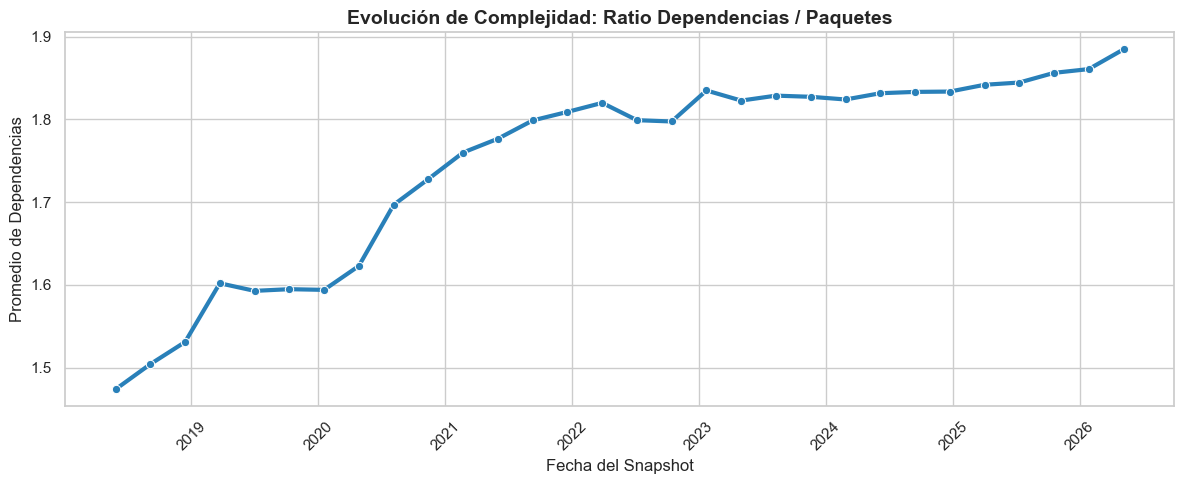

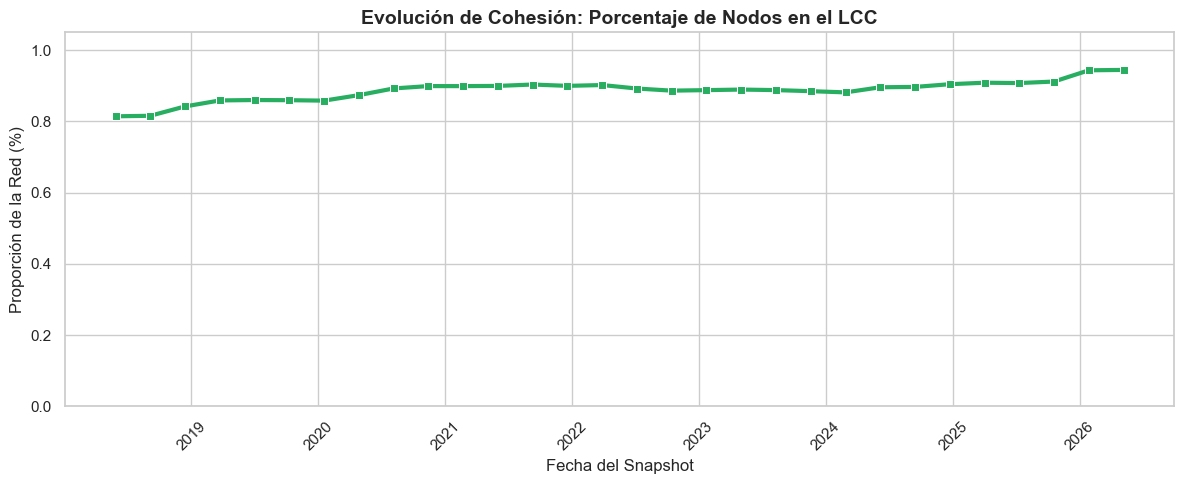

/var/folders/v5/kbcdcc412tb1kkysqm2lplxm0000gq/T/ipykernel_45657/2947672101.py:81: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(df_metrics[['Fecha', 'Ratio (Dependencias/Paquetes)', 'Proporción LCC']].round(3))


,Fecha,Ratio (Dependencias/Paquetes),Proporción LCC
0,2018-05-28,1.474,0.814
1,2018-09-05,1.504,0.816
2,2018-12-14,1.531,0.842
3,2019-03-24,1.602,0.859
4,2019-07-02,1.593,0.860
5,2019-10-10,1.595,0.859
6,2020-01-18,1.594,0.858
7,2020-04-27,1.623,0.874
8,2020-08-05,1.697,0.892
9,2020-11-13,1.728,0.899


In [11]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- 1. Configuración ---
gold_dir = Path("data/03_gold")
anchor_date = "2026-05-06"
target_dates = pd.date_range(end=anchor_date, periods=30, freq="100D")

resultados = []

print(f"Calculando Ratio Dependencias/Paquetes y Proporción LCC en {len(target_dates)} cortes...\n")

# --- 2. Iteración Histórica ---
for ts in target_dates:
    date_str = ts.strftime('%Y-%m-%d')
    edge_file = gold_dir / f"gold_edges_{date_str}.parquet"
    
    if not edge_file.exists():
        continue
        
    df_edges = pd.read_parquet(edge_file)
    G_std = nx.from_pandas_edgelist(df_edges, source='source_node', target='target_node', create_using=nx.DiGraph())
    
    num_nodes = G_std.number_of_nodes()
    num_edges = G_std.number_of_edges()
    
    if num_nodes == 0:
        continue
        
    # A. Ratio de Complejidad (Dependencias / Paquetes)
    dep_pkg_ratio = num_edges / num_nodes
    
    # B. Proporción del LCC (Largest Weakly Connected Component)
    largest_wcc = max(nx.weakly_connected_components(G_std), key=len)
    lcc_ratio = len(largest_wcc) / num_nodes
    
    resultados.append({
        'Fecha': ts,
        'Nodos': num_nodes,
        'Aristas': num_edges,
        'Ratio (Dependencias/Paquetes)': dep_pkg_ratio,
        'Proporción LCC': lcc_ratio
    })

df_metrics = pd.DataFrame(resultados)

# --- 3. Visualización Independiente ---
sns.set_theme(style="whitegrid")

# Gráfico 1: Ratio Dependencias / Paquetes
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_metrics, x='Fecha', y='Ratio (Dependencias/Paquetes)', 
    color='#2980B9', linewidth=3, marker='o'
)
plt.title("Evolución de Complejidad: Ratio Dependencias / Paquetes", fontsize=14, fontweight='bold')
plt.ylabel("Promedio de Dependencias")
plt.xlabel("Fecha del Snapshot", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico 2: Proporción del LCC
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_metrics, x='Fecha', y='Proporción LCC', 
    color='#27AE60', linewidth=3, marker='s'
)
plt.title("Evolución de Cohesión: Porcentaje de Nodos en el LCC", fontsize=14, fontweight='bold')
plt.ylabel("Proporción de la Red (%)")
plt.xlabel("Fecha del Snapshot", fontsize=12)
plt.ylim(0, 1.05) # Para visualizar del 0% al 100%
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Resumen en tabla
display(df_metrics[['Fecha', 'Ratio (Dependencias/Paquetes)', 'Proporción LCC']].round(3))